**Лабораторна робота №4 “Класифікація”**

**Мета роботи**: ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic.
Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


На цьому етапі було завантажено набір даних Titanic у DataFrame. У таблиці видно основні характеристики пасажирів: клас каюти, стать, вік, кількість родичів на борту, вартість квитка, порт посадки та цільову змінну Survived. Саме ознака Survived буде використовуватись як результат класифікації.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Після первинного аналізу даних було виявлено, що набір містить 891 запис і 12 колонок. Частина ознак має пропущені значення: Age, Cabin та Embarked. Найбільше пропусків містить колонка Cabin, тому її недоцільно використовувати для навчання моделі. Колонка Age має значну кількість пропусків, але вона є важливою для задачі, тому її потрібно заповнити.

In [6]:
data = df.copy()

data['Age'] = data['Age'].fillna(data['Age'].median())

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data = data.drop(columns=['Cabin'])

In [7]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Пропущені значення в колонці Age були заповнені медіанним віком, оскільки медіана менш чутлива до викидів, ніж середнє значення. Пропуски в Embarked були заповнені найчастішим значенням. Колонку Cabin було видалено через велику кількість пропусків, оскільки її використання могло б погіршити якість моделі.

In [8]:
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

Для побудови моделі всі категоріальні ознаки потрібно перетворити у числовий формат. Ознаку Sex було закодовано як 0 для чоловіків і 1 для жінок. Ознаку Embarked було перетворено за допомогою one-hot encoding, щоб модель могла коректно працювати з портами посадки.

In [9]:
data = data.drop(columns=['Name', 'Ticket', 'PassengerId'])

In [10]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


Колонки Name, Ticket та PassengerId були видалені, оскільки вони не мають прямого числового змісту для класифікації. PassengerId є лише ідентифікатором запису, Ticket має багато унікальних значень, а Name потребує додаткової складної обробки. Для базової моделі ці ознаки не використовуються.

In [11]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [12]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


У наборі даних спостерігається помірний дисбаланс класів: пасажирів, які не вижили, більше, ніж тих, хто вижив. Тому, окрім Accuracy, важливо аналізувати Precision, Recall та F1-score.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (712, 8)
Test: (179, 8)


Дані було поділено на навчальну та тестову вибірки у співвідношенні 80% до 20%. Навчальна вибірка використовується для побудови дерева рішень, а тестова — для перевірки якості моделі на нових даних. Такий поділ дозволяє оцінити, наскільки добре модель узагальнює закономірності.

In [15]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Було побудовано модель Decision Tree Classifier. Дерево рішень навчається шляхом послідовного поділу даних за ознаками, які найкраще розділяють пасажирів на тих, хто вижив, і тих, хто не вижив. Після навчання модель може прогнозувати клас для пасажирів із тестової вибірки.

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Глибина дерева:", model.get_depth())
print("Кількість вузлів:", model.tree_.node_count)

Глибина дерева: 21
Кількість вузлів: 357


Отримане дерево має досить велику глибину та значну кількість вузлів. Це означає, що модель детально підлаштувалася під навчальні дані. Занадто глибоке дерево може призводити до перенавчання, тому додатково було побудовано обмежене дерево з максимальною глибиною 5.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7877094972067039
Precision: 0.7432432432432432
Recall: 0.7432432432432432
F1-score: 0.7432432432432432


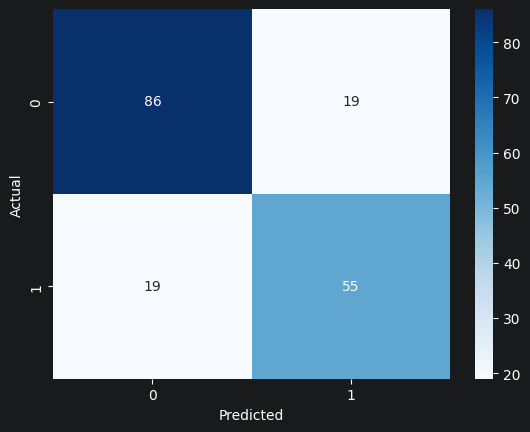

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Матриця помилок (confusion matrix) дозволяє детально проаналізувати результати класифікації моделі. Вона показує, скільки об’єктів було класифіковано правильно та неправильно для кожного класу.

У даному випадку отримано такі значення:
- 86 — істинно негативні (True Negative): пасажири, які не вижили, і модель правильно це передбачила;
- 55 — істинно позитивні (True Positive): пасажири, які вижили, і модель правильно це визначила;
- 19 — хибно позитивні (False Positive): модель передбачила виживання, але пасажир не вижив;
- 19 — хибно негативні (False Negative): модель передбачила, що пасажир не вижив, хоча він вижив.

Загалом кількість правильних класифікацій становить 86 + 55 = 141, а помилок — 19 + 19 = 38.

З матриці видно, що модель однаково часто помиляється в обох типах помилок (False Positive та False Negative). Це означає, що модель не має сильного перекосу в одну сторону і досить збалансовано визначає обидва класи.

Важливо звернути увагу на хибно негативні випадки (False Negative), оскільки це ситуації, коли модель не змогла виявити пасажирів, які вижили. У деяких задачах такі помилки можуть бути критичнішими, ніж хибно позитивні.

Матриця помилок підтверджує результати метрик: модель добре розпізнає клас "не вижив" (велике значення True Negative), але трохи гірше — клас "вижив". Це пов’язано з тим, що в наборі даних більше прикладів класу 0, ніж класу 1.

Таким чином, аналіз confusion matrix дозволяє зробити висновок, що модель працює стабільно, але має простір для покращення у визначенні пасажирів, які вижили.

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



Classification report підтверджує, що модель краще класифікує клас 0, тобто пасажирів, які не вижили. Для класу 1 метрики нижчі, що пов’язано з меншою кількістю таких прикладів у наборі даних. У цьому завданні найбільш інформативною метрикою є F1-score, оскільки вона враховує і Precision, і Recall.

In [21]:
model_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)
model_depth5.fit(X_train, y_train)

y_pred_depth5 = model_depth5.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_depth5))
print("Precision:", precision_score(y_test, y_pred_depth5))
print("Recall:", recall_score(y_test, y_pred_depth5))
print("F1-score:", f1_score(y_test, y_pred_depth5))

print("Глибина дерева:", model_depth5.get_depth())
print("Кількість вузлів:", model_depth5.tree_.node_count)

Accuracy: 0.7988826815642458
Precision: 0.8275862068965517
Recall: 0.6486486486486487
F1-score: 0.7272727272727273
Глибина дерева: 5
Кількість вузлів: 47


In [22]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
1,Sex,0.310280
5,Fare,0.263543
2,Age,0.206181
0,Pclass,0.111937
3,SibSp,0.059694
4,Parch,0.027496
7,Embarked_S,0.016200
6,Embarked_Q,0.004669


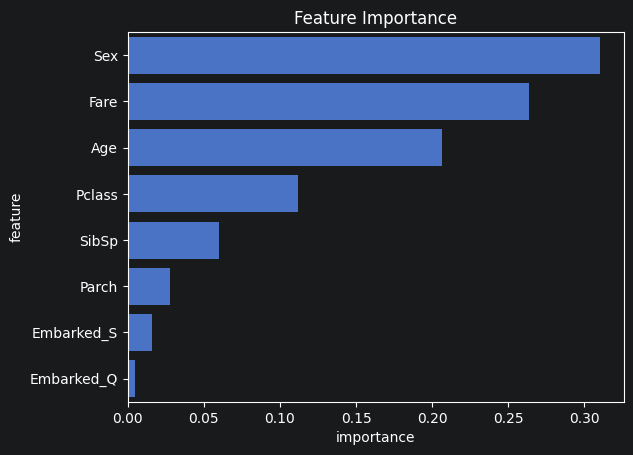

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

Найбільш важливою ознакою для прогнозування виживання є Sex, тобто стать пасажира. Також суттєвий вплив мають Fare, Age та Pclass. Це означає, що ймовірність виживання залежала від соціального статусу пасажира, вартості квитка, віку та статі.

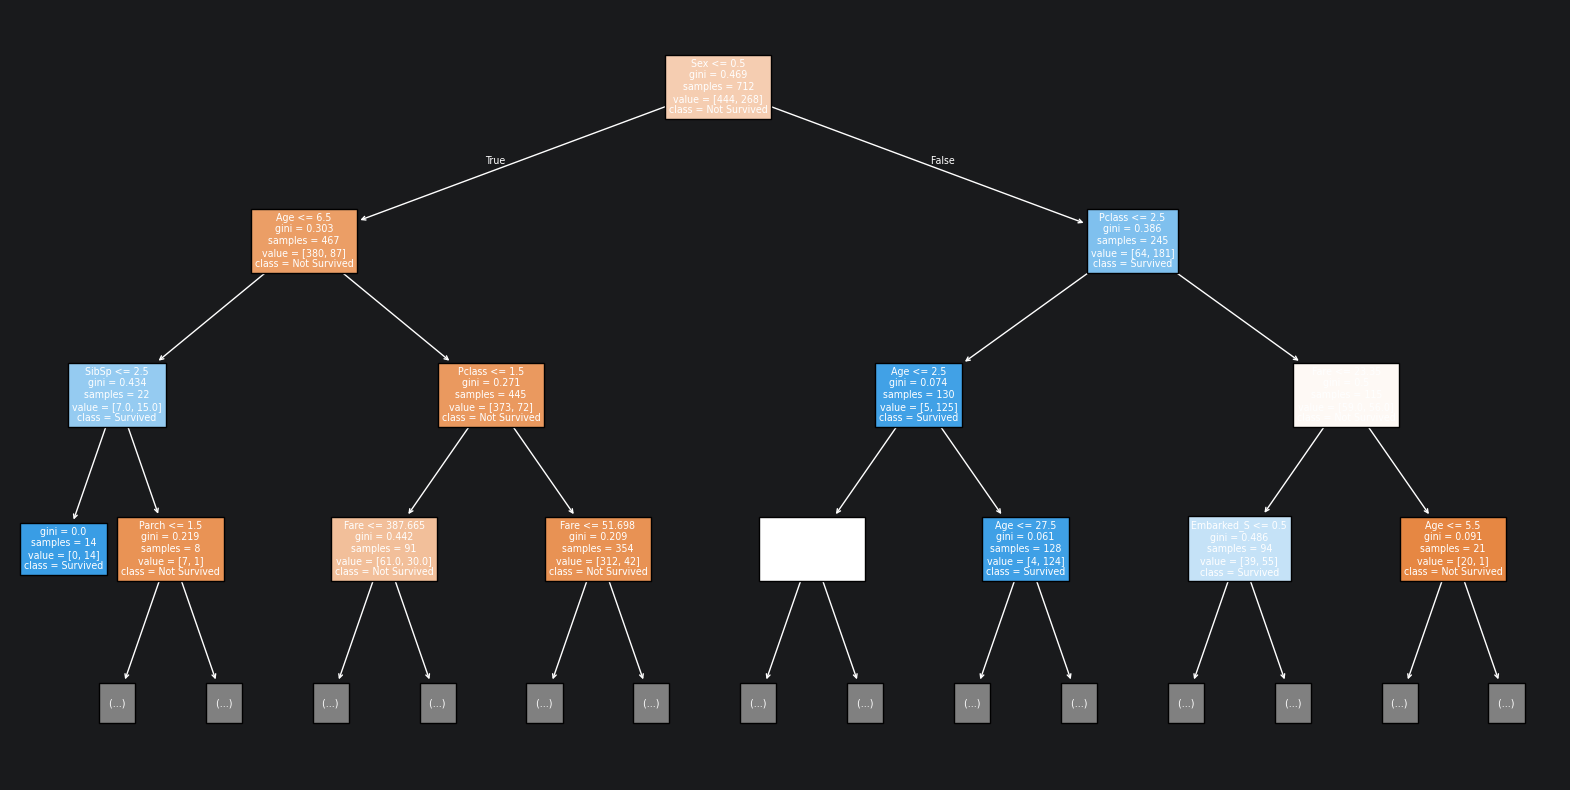

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model_depth5,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    max_depth=3
)

plt.show()

Отримане дерево рішень відображає логіку, за якою модель класифікує пасажирів на тих, хто вижив, і тих, хто не вижив. Кожен вузол дерева містить умову поділу за певною ознакою, а також статистику: значення критерію Gini, кількість об’єктів (samples) та розподіл класів (value).

Кореневий вузол використовує ознаку Sex, що означає, що саме стать є найбільш інформативною характеристикою для першого поділу даних. Якщо значення Sex ≤ 0.5 (тобто чоловік), модель переходить у ліву гілку, де переважає клас “не вижив”. Якщо Sex > 0.5 (тобто жінка), модель переходить у праву гілку, де значно більша ймовірність виживання.

У лівій частині дерева (чоловіки) наступним важливим фактором є вік (Age). Молодші пасажири мають дещо більший шанс вижити. Далі враховуються такі ознаки, як кількість родичів на борту (SibSp, Parch) та вартість квитка (Fare). Це свідчить про те, що навіть серед чоловіків виживання залежало від соціального статусу та сімейного положення.

У правій частині дерева (жінки) важливими ознаками є клас каюти (Pclass) та вік. Пасажири першого та другого класу мають значно вищу ймовірність виживання. Для жінок молодшого віку ймовірність виживання ще більша, що узгоджується з історичним принципом “жінки та діти — першими”.

Критерій Gini у вузлах показує ступінь “чистоти” розбиття. Чим менше значення Gini, тим більш однорідні об’єкти в цьому вузлі. У листових вузлах Gini наближається до нуля, що означає, що модель майже однозначно класифікує об’єкти.

Загалом дерево демонструє, що найважливішими факторами виживання були:
- стать (найсильніший вплив),
- клас каюти,
- вік,
- вартість квитка,
- сімейний стан.

Побудоване дерево є інтерпретованою моделлю: кожне рішення можна пояснити у вигляді послідовності умов. Це є головною перевагою дерев рішень у задачах аналізу даних.

**Висновки**: у ході виконання лабораторної роботи було розглянуто задачу класифікації на прикладі реального історичного набору даних Titanic. Було виконано повний цикл інтелектуального аналізу даних: від попередньої обробки до побудови та інтерпретації моделі.

На етапі підготовки даних було проведено аналіз структури датасету, виявлено пропущені значення та виконано їх обробку. Зокрема, пропуски у віці було заповнено медіаною, категоріальні ознаки перетворено у числовий формат, а неінформативні колонки видалено. Це дозволило підготувати дані до коректного навчання моделі.

Було побудовано класифікатор на основі дерева рішень. Модель показала задовільну якість: Accuracy становить близько 0.79, що означає правильну класифікацію приблизно 79% пасажирів. Додаткові метрики (Precision, Recall, F1-score) підтвердили, що модель працює збалансовано, хоча дещо краще розпізнає клас пасажирів, які не вижили.

Аналіз матриці помилок показав, що кількість хибно позитивних і хибно негативних результатів однакова, що свідчить про відсутність сильного перекосу моделі. Водночас модель має певні труднощі у визначенні пасажирів, які вижили, що частково пояснюється дисбалансом класів у даних.

Було також досліджено вплив глибини дерева. Обмеження глибини дозволило отримати простішу та більш інтерпретовану модель без суттєвої втрати якості, що свідчить про наявність перенавчання у повному дереві.

Інтерпретація моделі показала, що найважливішими факторами виживання є стать пасажира, клас каюти, вік та вартість квитка. Це відповідає історичним фактам, згідно з якими жінки, діти та пасажири вищих класів мали більші шанси на порятунок.

Отже, у результаті виконання роботи було отримано практичні навички побудови класифікаційної моделі, оцінювання її якості та інтерпретації результатів. Дерево рішень продемонструвало свою ефективність як простий та наочний метод класифікації, який дозволяє не лише прогнозувати, але й пояснювати прийняті рішення.